# Kanji Recognition — HOG + Classical ML

**Pipeline 3 bước:**
1. Trực quan, Phân tích Dữ liệu & Tiền xử lý
2. Xây dựng các mô hình & Tinh chỉnh
3. So sánh, Đánh giá & Khuyến nghị



##  0. Cài đặt thư viện

In [ ]:
!pip install xgboost scikit-image scikit-learn joblib opencv-python-headless matplotlib seaborn pandas -q

In [ ]:
import os, random, warnings
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
import subprocess
import seaborn as sns

from skimage.feature import hog
from skimage import exposure

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.decomposition   import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay)

from sklearn.svm             import SVC, LinearSVC
from sklearn.ensemble        import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier



warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print(' Thư viện đã sẵn sàng')

 Thư viện đã sẵn sàng


##  Mount Google Drive & cấu hình đường dẫn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Chỉnh đường dẫn cho đúng vị trí dataset của bạn ──
DATASET_DIR = '/content/drive/MyDrive/dataset_output_N5'
SAVE_DIR    = '/content/drive/MyDrive/trained_models'
IMG_SIZE    = (64, 64)

os.makedirs(SAVE_DIR, exist_ok=True)
print('📂 DATASET_DIR:', DATASET_DIR)
print('💾 SAVE_DIR   :', SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 DATASET_DIR: /content/drive/MyDrive/dataset_output_N5
💾 SAVE_DIR   : /content/drive/MyDrive/trained_models


---
#  BƯỚC 1 — Trực quan, Phân tích Dữ liệu & Tiền xử lý

### 1.1 Thống kê tổng quan dataset

In [ ]:
class_info = []
for entry in sorted(os.scandir(DATASET_DIR), key=lambda e: e.name):
    if entry.is_dir():
        imgs = [f for f in os.scandir(entry.path) if f.is_file()]
        class_info.append({'class': entry.name, 'count': len(imgs)})

df_info = pd.DataFrame(class_info)
print(f'Tổng số class (kanji): {len(df_info)}')
print(f'Tổng số ảnh          : {df_info["count"].sum()}')
print(f'Trung bình / class   : {df_info["count"].mean():.1f}')
print(f'Min / Max            : {df_info["count"].min()} / {df_info["count"].max()}')
display(df_info.describe())

Tổng số class (kanji): 80
Tổng số ảnh          : 16079
Trung bình / class   : 201.0
Min / Max            : 200 / 201


,count
count,80.000000
mean,200.987500
std,0.111803
min,200.000000
25%,201.000000
50%,201.000000
75%,201.000000
max,201.000000


### 1.2 Phân phối số ảnh theo class

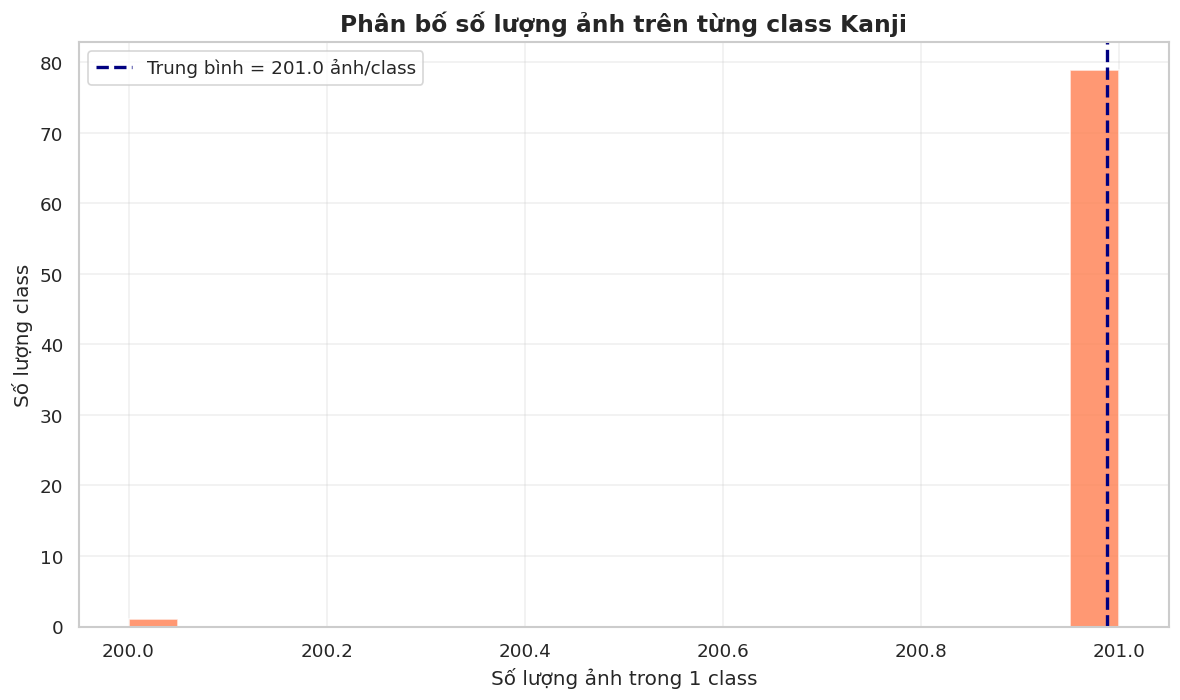

In [ ]:
# ==================== HISTOGRAM PHÂN BỐ SỐ ẢNH / CLASS ====================

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram phân phối
ax.hist(df_info['count'], bins=20, color='coral', edgecolor='white', alpha=0.8)

# Đường trung bình
ax.axvline(df_info['count'].mean(), color='navy', linestyle='--',
           linewidth=2, label=f'Trung bình = {df_info["count"].mean():.1f} ảnh/class')

ax.set_title('Phân bố số lượng ảnh trên từng class Kanji', fontsize=14, fontweight='bold')
ax.set_xlabel('Số lượng ảnh trong 1 class', fontsize=12)
ax.set_ylabel('Số lượng class', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 1.4 Tiền xử lý & trực quan so sánh các bước

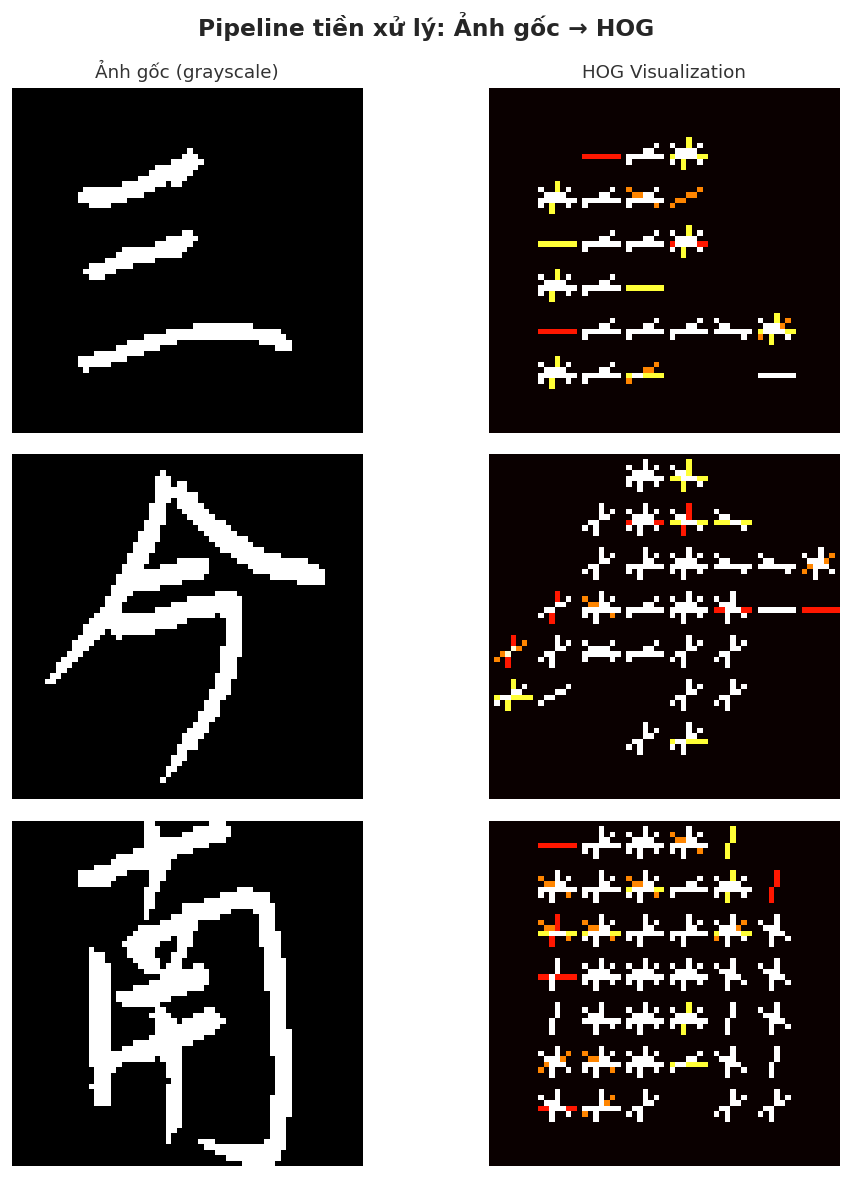

In [ ]:
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, flags)

def preprocess_image(path):
    img = imread_unicode(path)
    if img is None:
        return None
    # Chỉ đọc ảnh, không resize, không Otsu
    return img


def extract_hog(img):
    features, hog_img = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True,
        visualize=True
    )
    return features, hog_img


# ==================== HIỂN THỊ PIPELINE MỚI ====================
demo_classes = random.sample(list(df_info['class']), 3)

fig, axes = plt.subplots(3, 2, figsize=(9, 10))
fig.suptitle('Pipeline tiền xử lý: Ảnh gốc → HOG',
             fontsize=14, fontweight='bold')

col_titles = ['Ảnh gốc (grayscale)', 'HOG Visualization']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, color='#333')

for row, cls in enumerate(demo_classes):
    cls_dir = os.path.join(DATASET_DIR, cls)
    img_path = next(f.path for f in os.scandir(cls_dir) if f.is_file())

    raw = imread_unicode(img_path)                    # Ảnh gốc
    proc = preprocess_image(img_path)                 # Hiện tại chỉ đọc ảnh
    _, hog_vis = extract_hog(proc)
    hog_vis = exposure.rescale_intensity(hog_vis, in_range=(0, 10))

    # Vẽ 2 cột
    for col, (im, cmap) in enumerate([(raw, 'gray'), (hog_vis, 'hot')]):
        axes[row][col].imshow(im, cmap=cmap)
        axes[row][col].set_ylabel(cls, fontsize=10, fontweight='bold') if col == 0 else None
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

### 1.5 Load toàn bộ dataset & trích xuất đặc trưng HOG

In [ ]:
X, y = [], []
skipped = 0

for class_entry in sorted(os.scandir(DATASET_DIR), key=lambda e: e.name):
    if not class_entry.is_dir():
        continue
    label = class_entry.name
    for img_entry in os.scandir(class_entry.path):
        if not img_entry.is_file():
            continue
        img = preprocess_image(img_entry.path)
        if img is None:
            skipped += 1
            continue
        feat, _ = extract_hog(img)
        X.append(feat)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f'Tổng ảnh đã load  : {len(X)}')
print(f'Ảnh bỏ qua (lỗi) : {skipped}')
print(f'Số class          : {len(set(y))}')
print(f'Kích thước feature : {X.shape[1]} chiều')

if len(X) == 0:
    raise ValueError('Không load được ảnh nào. Kiểm tra lại DATASET_DIR.')

Tổng ảnh đã load  : 16079
Ảnh bỏ qua (lỗi) : 0
Số class          : 80
Kích thước feature : 1512 chiều


### 1.6 Phân tích đặc trưng HOG (phân phối, PCA explained variance)

Train: 12863 | Test: 3216


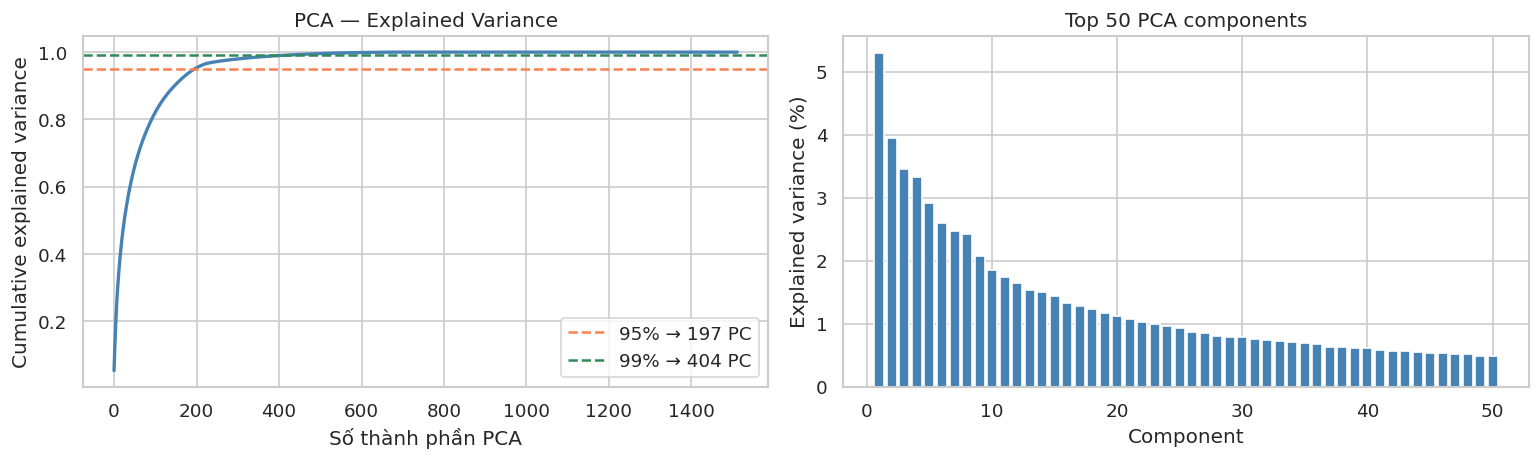

  Giữ 95% variance → cần 197 / 1512 thành phần
  Giữ 99% variance → cần 404 / 1512 thành phần


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# PCA analysis
pca_full = PCA(random_state=SEED).fit(X_train_sc)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n95 = np.searchsorted(cum_var, 0.95) + 1
n99 = np.searchsorted(cum_var, 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(cum_var, color='steelblue', linewidth=2)
axes[0].axhline(0.95, color='coral',  linestyle='--', label=f'95% → {n95} PC')
axes[0].axhline(0.99, color='seagreen', linestyle='--', label=f'99% → {n99} PC')
axes[0].set_xlabel('Số thành phần PCA')
axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title('PCA — Explained Variance')
axes[0].legend()

axes[1].bar(range(1, 51), pca_full.explained_variance_ratio_[:50]*100,
            color='steelblue', edgecolor='white')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Explained variance (%)')
axes[1].set_title('Top 50 PCA components')

plt.tight_layout()
plt.show()
print(f'  Giữ 95% variance → cần {n95} / {X.shape[1]} thành phần')
print(f'  Giữ 99% variance → cần {n99} / {X.shape[1]} thành phần')

---
# BƯỚC 2 — Xây dựng các mô hình & Tinh chỉnh

### 2.1 Định nghĩa pipeline & các mô hình

In [ ]:
models = {
    'SVM (RBF)': SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, class_weight='balanced'
    ),
    'SVM (Linear)': LinearSVC(
        C=1.0, class_weight='balanced', max_iter=5000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, n_jobs=-1,
        random_state=SEED, class_weight='balanced'
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=3000, n_jobs=-1, class_weight='balanced'
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        objective='multi:softprob', eval_metric='mlogloss',
        tree_method='hist', n_jobs=-1, random_state=SEED
    ),
}

def make_pipeline(clf):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=SEED)),
        ('model',  clf)
    ])

print(f'Tổng số mô hình cần train: {len(models)}')

Tổng số mô hình cần train: 7


### 2.2 Train tất cả mô hình & lưu kết quả

In [ ]:
results     = []
pipelines   = {}
predictions = {}

for name, clf in models.items():
    print(f'\n{'='*55}')
    print(f'  🔧 Training: {name}')
    print(f'{'='*55}')

    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
        output_dict=True
    )

    macro_f1  = report['macro avg']['f1-score']
    macro_pre = report['macro avg']['precision']
    macro_rec = report['macro avg']['recall']

    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Macro F1  : {macro_f1:.4f}')
    print(f'  Macro Pre : {macro_pre:.4f}')
    print(f'  Macro Rec : {macro_rec:.4f}')

    save_path = os.path.join(SAVE_DIR, f'{name.replace(" ","_")}_hog_pca.pkl')
    joblib.dump({'model': pipe, 'label_encoder': label_encoder,
                 'img_size': IMG_SIZE, 'model_name': name, 'accuracy': acc}, save_path)

    pipelines[name]   = pipe
    predictions[name] = y_pred

    results.append({
        'Model': name, 'Accuracy': acc,
        'Macro F1': macro_f1, 'Macro Precision': macro_pre,
        'Macro Recall': macro_rec, 'Path': save_path
    })

df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1
print('\n Đã train xong tất cả mô hình!')


  🔧 Training: SVM (RBF)
  Accuracy  : 0.9801
  Macro F1  : 0.9801
  Macro Pre : 0.9808
  Macro Rec : 0.9801

  🔧 Training: SVM (Linear)
  Accuracy  : 0.9179
  Macro F1  : 0.9178
  Macro Pre : 0.9197
  Macro Rec : 0.9180

  🔧 Training: Random Forest
  Accuracy  : 0.9192
  Macro F1  : 0.9190
  Macro Pre : 0.9217
  Macro Rec : 0.9193

  🔧 Training: Logistic Regression
  Accuracy  : 0.9571
  Macro F1  : 0.9573
  Macro Pre : 0.9587
  Macro Rec : 0.9571

  🔧 Training: KNN
  Accuracy  : 0.9316
  Macro F1  : 0.9317
  Macro Pre : 0.9347
  Macro Rec : 0.9317

  🔧 Training: Naive Bayes
  Accuracy  : 0.8955
  Macro F1  : 0.8974
  Macro Pre : 0.9037
  Macro Rec : 0.8957

  🔧 Training: XGBoost
  Accuracy  : 0.8803
  Macro F1  : 0.8805
  Macro Pre : 0.8833
  Macro Rec : 0.8805

 Đã train xong tất cả mô hình!


### 2.3 Tinh chỉnh mô hình tốt nhất (GridSearch nhẹ)

In [ ]:
from sklearn.model_selection import GridSearchCV

best_name = df_results.iloc[0]['Model']
print(f' Mô hình tốt nhất ban đầu: {best_name}')

# Tinh chỉnh SVM RBF nếu là best (hoặc đổi logic theo kết quả thực tế)
if 'SVM' in best_name and 'RBF' in best_name:
    param_grid = {'model__C': [1, 5, 10, 20], 'model__gamma': ['scale', 'auto']}
    base_clf = SVC(kernel='rbf', probability=True, class_weight='balanced')
elif 'Logistic' in best_name:
    param_grid = {'model__C': [0.1, 1, 5, 10]}
    base_clf = LogisticRegression(max_iter=3000, n_jobs=-1, class_weight='balanced')
elif 'XGBoost' in best_name:
    param_grid = {'model__n_estimators': [300, 500], 'model__max_depth': [4, 6]}
    base_clf = XGBClassifier(learning_rate=0.05, objective='multi:softprob',
                              eval_metric='mlogloss', tree_method='hist',
                              n_jobs=-1, random_state=SEED)
else:
    param_grid = {}
    base_clf = list(models.values())[0]

if param_grid:
    tune_pipe = make_pipeline(base_clf)
    gs = GridSearchCV(tune_pipe, param_grid, cv=3,
                      scoring='accuracy', n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)

    tuned_acc = accuracy_score(y_test, gs.predict(X_test))
    print(f'\n Best params : {gs.best_params_}')
    print(f'   Accuracy sau tinh chỉnh : {tuned_acc:.4f}')
    print(f'   Accuracy trước tinh chỉnh: {df_results.iloc[0]["Accuracy"]:.4f}')

    # Cập nhật kết quả nếu tốt hơn
    if tuned_acc > df_results.iloc[0]['Accuracy']:
        pipelines[f'{best_name} (tuned)'] = gs.best_estimator_
        predictions[f'{best_name} (tuned)'] = gs.predict(X_test)
        print('  → Mô hình đã được cải thiện!')
    else:
        print('  → Không cải thiện đáng kể; giữ nguyên hyperparameter gốc.')
else:
    print('Không có param_grid cho mô hình này — bỏ qua bước tinh chỉnh.')

 Mô hình tốt nhất ban đầu: SVM (RBF)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

 Best params : {'model__C': 5, 'model__gamma': 'scale'}
   Accuracy sau tinh chỉnh : 0.9801
   Accuracy trước tinh chỉnh: 0.9801
  → Không cải thiện đáng kể; giữ nguyên hyperparameter gốc.


---
# 📈 BƯỚC 3 — So sánh, Đánh giá & Khuyến nghị

### 3.1 Bảng so sánh tổng hợp

In [ ]:
display_cols = ['Model', 'Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']

styled = (df_results[display_cols]
          .style
          .format({'Accuracy': '{:.4f}', 'Macro F1': '{:.4f}',
                   'Macro Precision': '{:.4f}', 'Macro Recall': '{:.4f}'})
          .background_gradient(subset=['Accuracy', 'Macro F1'], cmap='YlGn')
          .set_caption(' Kết quả so sánh các mô hình trên tập Test')
          .set_table_styles([{
              'selector': 'caption',
              'props': [('font-size', '14px'), ('font-weight', 'bold')]
          }])
         )
display(styled)

,Model,Accuracy,Macro F1,Macro Precision,Macro Recall
1,SVM (RBF),0.9801,0.9801,0.9808,0.9801
2,Logistic Regression,0.9571,0.9573,0.9587,0.9571
3,KNN,0.9316,0.9317,0.9347,0.9317
4,Random Forest,0.9192,0.9190,0.9217,0.9193
5,SVM (Linear),0.9179,0.9178,0.9197,0.9180
6,Naive Bayes,0.8955,0.8974,0.9037,0.8957
7,XGBoost,0.8803,0.8805,0.8833,0.8805


### 3.2 Biểu đồ so sánh đa chỉ số

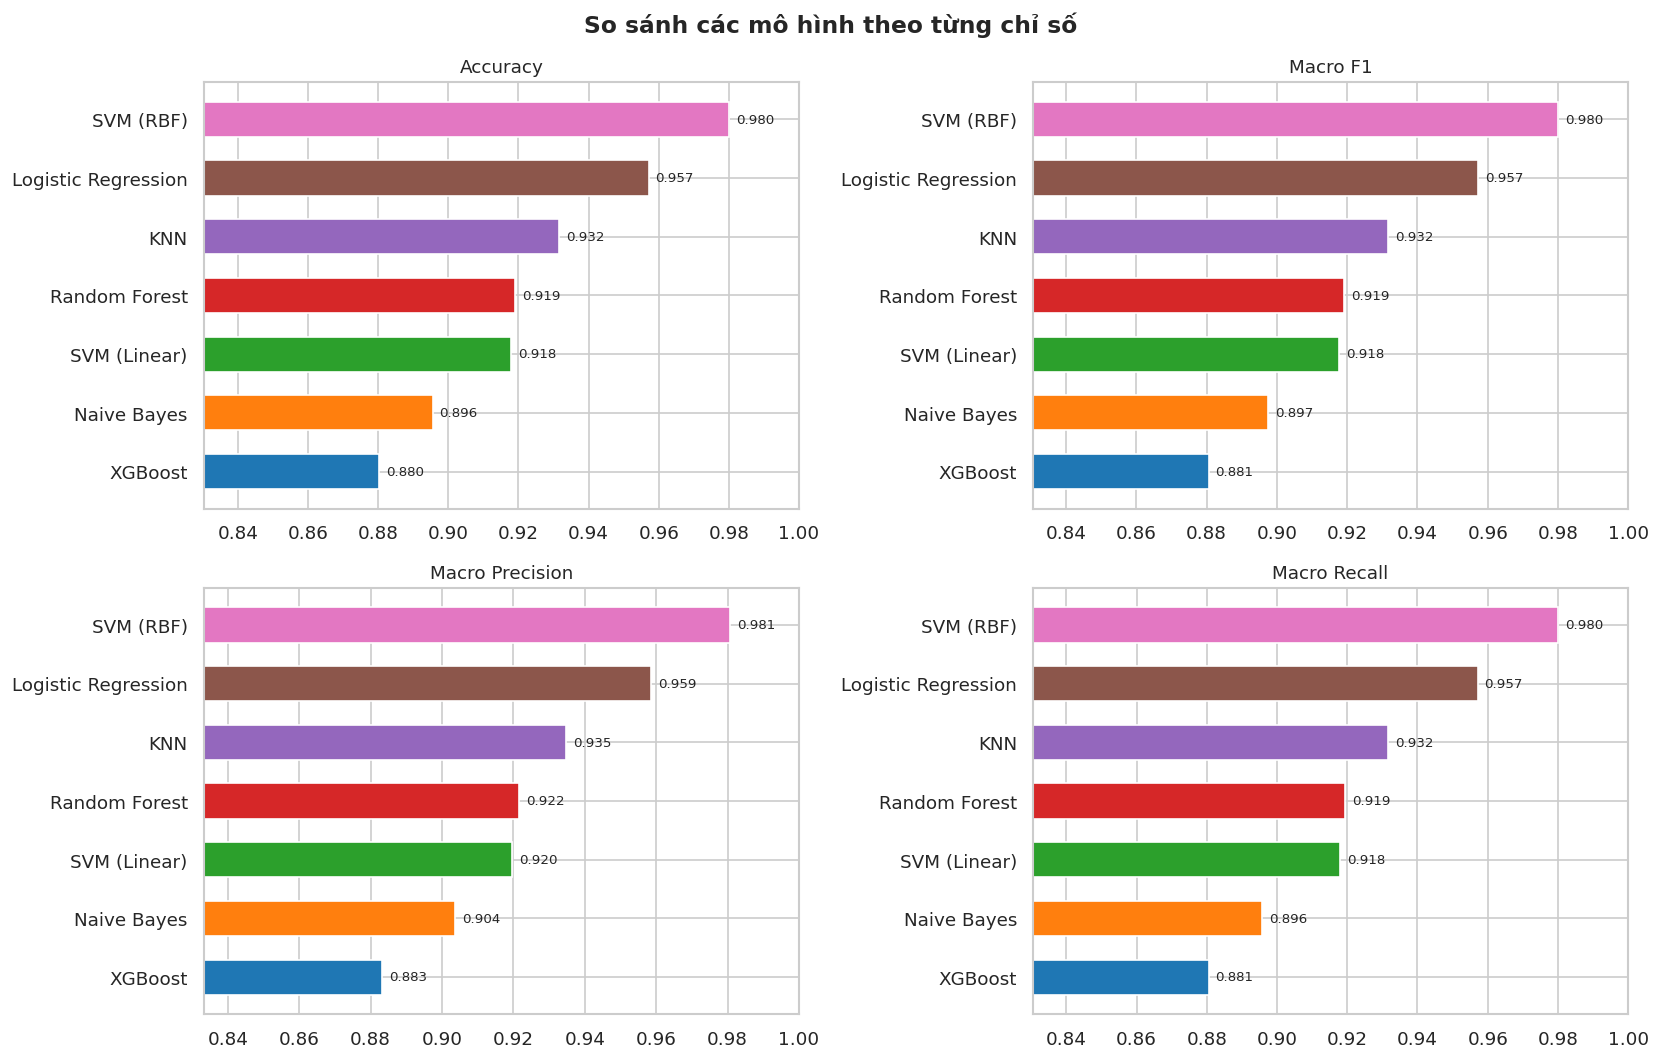

In [ ]:
metrics = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
df_plot = df_results[['Model'] + metrics].set_index('Model')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('So sánh các mô hình theo từng chỉ số', fontsize=14, fontweight='bold')

colors = plt.cm.tab10.colors

for ax, metric in zip(axes.flat, metrics):
    vals = df_plot[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values,
                   color=colors[:len(vals)], edgecolor='white', height=0.6)
    ax.set_xlim(max(0, vals.min() - 0.05), min(1.0, vals.max() + 0.05))
    ax.set_title(metric, fontsize=11)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Radar chart — so sánh đa chiều

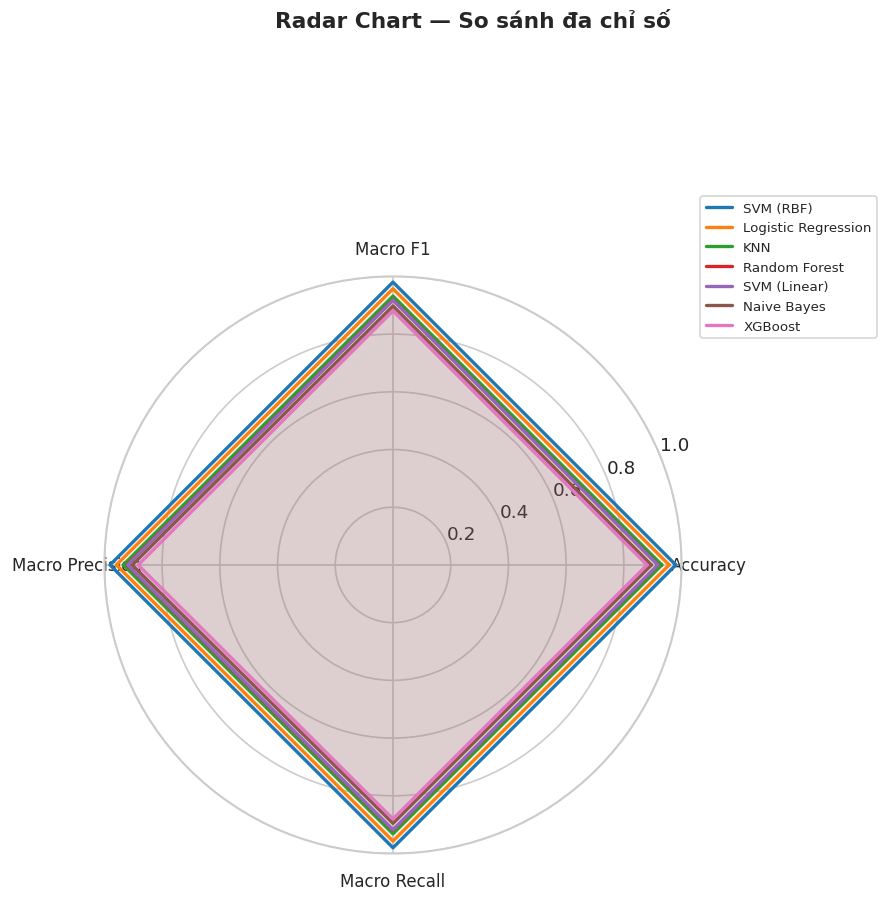

In [ ]:
from matplotlib.patches import FancyArrowPatch

categories = metrics
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart — So sánh đa chỉ số', fontsize=13, fontweight='bold', y=1.02)

for i, (idx, row) in enumerate(df_results.iterrows()):
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid',
            label=row['Model'], color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.05, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

### 3.4 Confusion Matrix — Top 3 mô hình

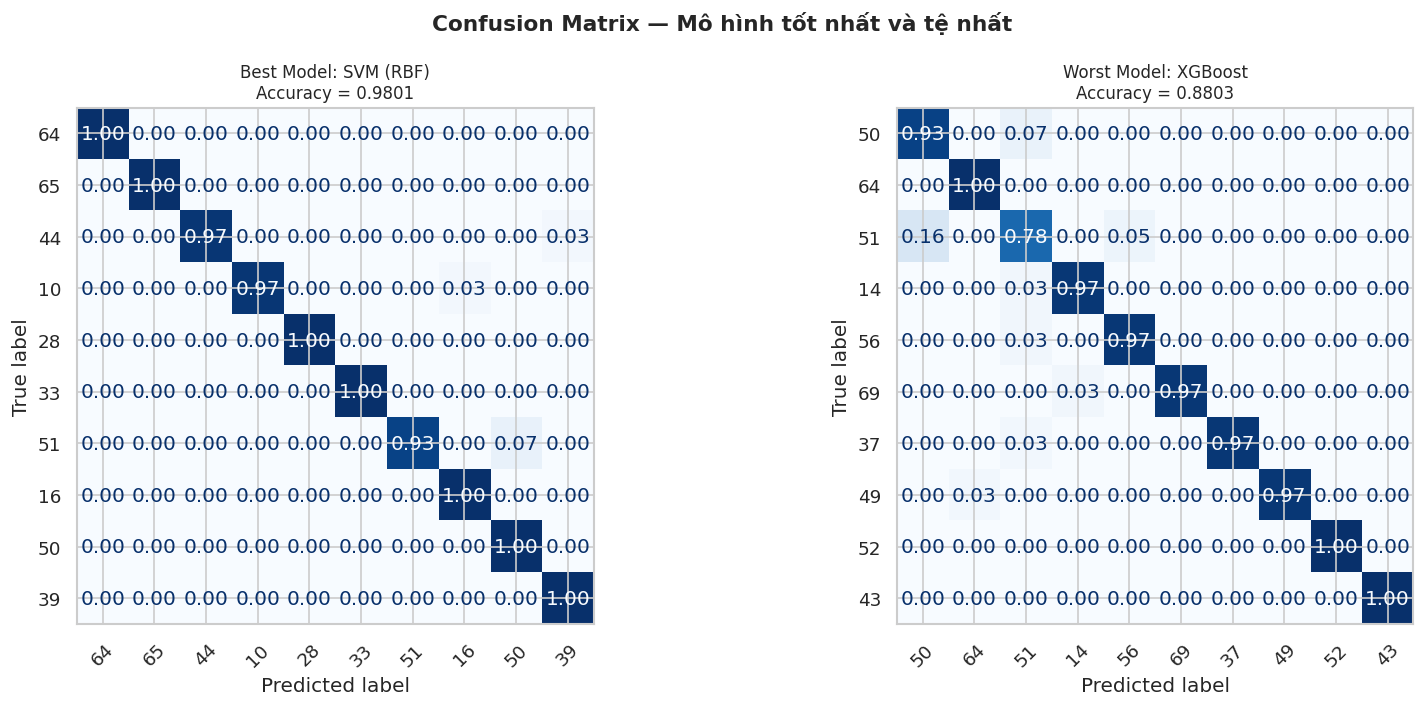

,Class ID,Kanji
0,C0,一
1,C1,七
2,C2,万
3,C3,三
4,C4,上
...,...,...
75,C75,間
76,C76,雨
77,C77,電
78,C78,食


In [ ]:
# Model tốt nhất và tệ nhất
best_model = df_results.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
worst_model = df_results.sort_values("Accuracy", ascending=True).iloc[0]["Model"]

selected_models = [best_model, worst_model]

TOP_N = 10

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Confusion Matrix — Mô hình tốt nhất và tệ nhất",
    fontsize=13,
    fontweight="bold"
)

for ax, name in zip(axes, selected_models):

    cm = confusion_matrix(y_test, predictions[name])

    # Số lỗi của từng class
    errors_per_class = cm.sum(axis=1) - np.diag(cm)

    # Top class bị nhầm nhiều nhất
    top_error_idx = np.argsort(errors_per_class)[::-1][:TOP_N]

    cm_small = cm[np.ix_(top_error_idx, top_error_idx)]

    # Chuẩn hóa theo hàng
    cm_norm = cm_small.astype(float) / cm_small.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    labels = top_error_idx

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format=".2f",
        xticks_rotation=45
    )

    acc = df_results.loc[
        df_results["Model"] == name,
        "Accuracy"
    ].values[0]

    title_type = "Best Model" if name == best_model else "Worst Model"

    ax.set_title(
        f"{title_type}: {name}\nAccuracy = {acc:.4f}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

mapping_df = pd.DataFrame({
    "Class ID": [f"C{i}" for i in range(len(label_encoder.classes_))],
    "Kanji": label_encoder.classes_
})

display(mapping_df)

### 3.5 Per-class F1 — mô hình tốt nhất

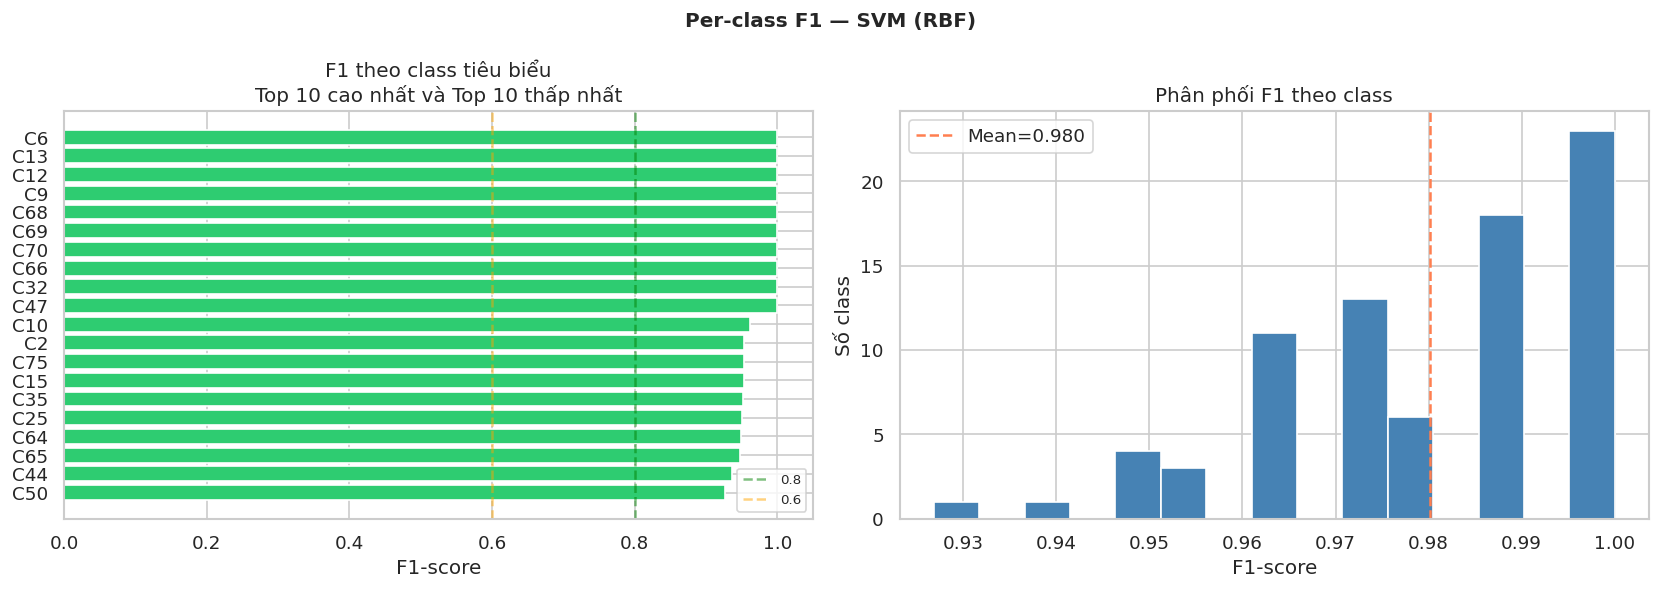

,Class ID,Kanji
0,C0,一
1,C1,七
2,C2,万
3,C3,三
4,C4,上
...,...,...
75,C75,間
76,C76,雨
77,C77,電
78,C78,食



  0 class có F1 < 0.6 (cần cải thiện):


,class,precision,recall,f1-score,support


In [ ]:
best_name = df_results.iloc[0]['Model']

report_dict = classification_report(
    y_test, predictions[best_name],
    target_names=label_encoder.classes_,
    zero_division=0,
    output_dict=True
)

per_class = pd.DataFrame({
    cls: report_dict[cls]
    for cls in label_encoder.classes_
}).T.reset_index().rename(columns={'index': 'class'})

per_class_sorted = per_class.sort_values('f1-score', ascending=False)

# Lấy Top 10 tốt nhất và Top 10 thấp nhất
top_good = per_class_sorted.head(10)
top_bad = per_class_sorted.tail(10)

per_class_plot = pd.concat([top_good, top_bad])
per_class_plot = per_class_plot.sort_values('f1-score', ascending=False)
per_class_plot = per_class_plot.copy()
per_class_plot['class_show'] = [f"C{i}" for i in per_class_plot.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Per-class F1 — {best_name}', fontsize=12, fontweight='bold')

# F1 by class — chỉ vẽ một số class tiêu biểu
palette = [
    '#2ecc71' if v >= 0.8 else '#e67e22' if v >= 0.6 else '#e74c3c'
    for v in per_class_plot['f1-score']
]

axes[0].barh(
    per_class_plot['class_show'],
    per_class_plot['f1-score'],
    color=palette,
    edgecolor='white'
)

axes[0].axvline(0.8, color='green', linestyle='--', alpha=0.5, label='0.8')
axes[0].axvline(0.6, color='orange', linestyle='--', alpha=0.5, label='0.6')
axes[0].set_xlabel('F1-score')
axes[0].set_title('F1 theo class tiêu biểu\nTop 10 cao nhất và Top 10 thấp nhất')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# Histogram F1 distribution — giữ nguyên
axes[1].hist(per_class['f1-score'], bins=15, color='steelblue', edgecolor='white')
axes[1].axvline(
    per_class['f1-score'].mean(),
    color='coral',
    linestyle='--',
    label=f'Mean={per_class["f1-score"].mean():.3f}'
)
axes[1].set_xlabel('F1-score')
axes[1].set_ylabel('Số class')
axes[1].set_title('Phân phối F1 theo class')
axes[1].legend()

plt.tight_layout()
plt.show()

mapping_df = pd.DataFrame({
    "Class ID": [f"C{i}" for i in range(len(label_encoder.classes_))],
    "Kanji": label_encoder.classes_
})

display(mapping_df)

low_f1 = per_class[per_class['f1-score'] < 0.6].sort_values('f1-score')

print(f'\n  {len(low_f1)} class có F1 < 0.6 (cần cải thiện):')
display(low_f1[['class', 'precision', 'recall', 'f1-score', 'support']].round(3))

### 3.6 Cross-validation — top 3 mô hình

SVM (RBF): 0.9740 ± 0.0027
Logistic Regression: 0.9537 ± 0.0040
KNN: 0.9338 ± 0.0024


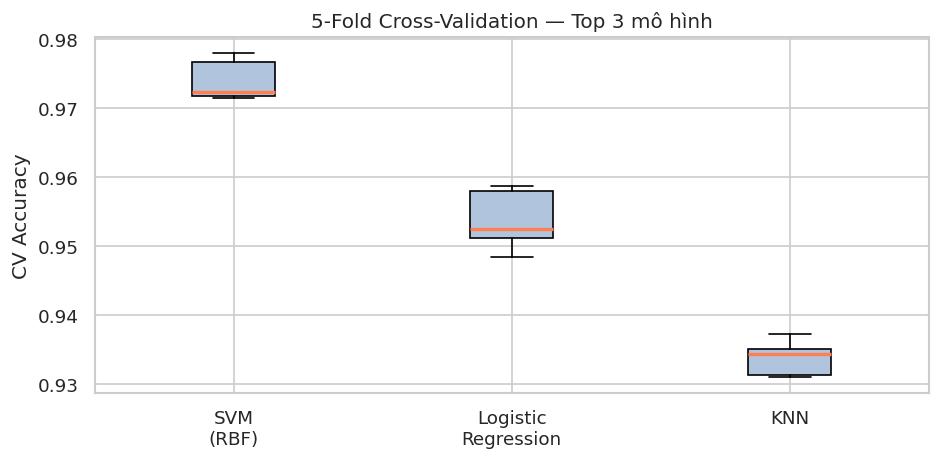

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

top3_names = list(
    df_results.sort_values("Accuracy", ascending=False)
              .head(3)["Model"]
)

for name in top3_names:
    pipe_cv = make_pipeline(models[name])
    scores  = cross_val_score(pipe_cv, X, y_encoded,
                               cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_results[n] for n in top3_names],
           labels=[n.replace(' ', '\n') for n in top3_names],
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'),
           medianprops=dict(color='coral', linewidth=2))
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation — Top 3 mô hình')
plt.tight_layout()
plt.show()

### 3.7 Dự đoán mẫu — kiểm tra trực quan

In [ ]:
best_pipe = pipelines[best_name]

sample_idx = random.sample(
    range(len(X_test)),
    min(10, len(X_test))
)

sample_rows = []

for idx in sample_idx:
    true_id = y_test[idx]
    pred_id = predictions[best_name][idx]

    sample_rows.append({
        "Sample Index": idx,
        "True Class": f"C{true_id}",
        "Pred Class": f"C{pred_id}",
        "Correct": "Đúng" if true_id == pred_id else "Sai"
    })

sample_table = pd.DataFrame(sample_rows)

display(sample_table)

,Sample Index,True Class,Pred Class,Correct
0,1857,C30,C30,Đúng
1,2603,C43,C43,Đúng
2,1494,C37,C37,Đúng
3,666,C42,C42,Đúng
4,1516,C28,C28,Đúng
5,1455,C65,C65,Đúng
6,858,C33,C33,Đúng
7,2745,C69,C69,Đúng
8,1093,C11,C11,Đúng
9,2874,C32,C32,Đúng


### 3.8 Tổng kết & Khuyến nghị

In [ ]:
best   = df_results.iloc[0]
second = df_results.iloc[1]
worst  = df_results.iloc[-1]

print('=' * 60)
print('   TỔNG KẾT & KHUYẾN NGHỊ')
print('=' * 60)

print(f"""
MÔ HÌNH TỐT NHẤT  : {best['Model']}
   Accuracy          : {best['Accuracy']:.4f}
   Macro F1          : {best['Macro F1']:.4f}

MÔ HÌNH THỨ HAI   : {second['Model']}
   Accuracy          : {second['Accuracy']:.4f}

MÔ HÌNH YẾU NHẤT  : {worst['Model']}
   Accuracy          : {worst['Accuracy']:.4f}
""")

print('PHÂN TÍCH:')
print('HOG + PCA là pipeline feature extraction hiệu quả cho nhận dạng chữ.')
print(f' PCA giữ 95% variance giúp giảm từ {X.shape[1]} → {n95} chiều.')
print('  class_weight="balanced" giúp các mô hình xử lý mất cân bằng dữ liệu.')

print('\nKHUYẾN NGHỊ:')
print(f'  1. Triển khai sản phẩm: dùng [{best["Model"]}] — accuracy cao nhất, đã lưu tại {best["Path"]}.')
print(f'  2. Nếu cần tốc độ inference nhanh hơn: [{second["Model"]}] là lựa chọn thay thế.')
print('  3. Tăng cường dữ liệu (augmentation: rotation, dilation) cho các class F1 thấp.')
print('  4. Thử CNN (EfficientNet, ResNet) nếu có GPU — thường vượt trội HOG+SVM với ảnh phức tạp.')
print('  5. Tích hợp SRS (Spaced Repetition) để cá nhân hóa học tập trên website Kanji.')

print('\n' + '=' * 60)
display(df_results[display_cols])

   TỔNG KẾT & KHUYẾN NGHỊ

MÔ HÌNH TỐT NHẤT  : SVM (RBF)
   Accuracy          : 0.9801
   Macro F1          : 0.9801

MÔ HÌNH THỨ HAI   : Logistic Regression
   Accuracy          : 0.9571

MÔ HÌNH YẾU NHẤT  : XGBoost
   Accuracy          : 0.8803

PHÂN TÍCH:
HOG + PCA là pipeline feature extraction hiệu quả cho nhận dạng chữ.
 PCA giữ 95% variance giúp giảm từ 1512 → 197 chiều.
  class_weight="balanced" giúp các mô hình xử lý mất cân bằng dữ liệu.

KHUYẾN NGHỊ:
  1. Triển khai sản phẩm: dùng [SVM (RBF)] — accuracy cao nhất, đã lưu tại /content/drive/MyDrive/trained_models/SVM_(RBF)_hog_pca.pkl.
  2. Nếu cần tốc độ inference nhanh hơn: [Logistic Regression] là lựa chọn thay thế.
  3. Tăng cường dữ liệu (augmentation: rotation, dilation) cho các class F1 thấp.
  4. Thử CNN (EfficientNet, ResNet) nếu có GPU — thường vượt trội HOG+SVM với ảnh phức tạp.
  5. Tích hợp SRS (Spaced Repetition) để cá nhân hóa học tập trên website Kanji.



,Model,Accuracy,Macro F1,Macro Precision,Macro Recall
1,SVM (RBF),0.980100,0.980120,0.980778,0.980122
2,Logistic Regression,0.957090,0.957253,0.958663,0.957096
3,KNN,0.931592,0.931735,0.934676,0.931677
4,Random Forest,0.919154,0.918993,0.921678,0.919291
5,SVM (Linear),0.917910,0.917784,0.919684,0.917973
6,Naive Bayes,0.895522,0.897354,0.903709,0.895671
7,XGBoost,0.880286,0.880545,0.883275,0.880503
